# 实践:在Typedict定义单输入输出模式

0.初始化输入输出状态

! pip install langchain==0.3.3
! pip install langchain-openai
! pip install langgraph==0.2.60

In [5]:
from langgraph.graph import StateGraph # 导入 StateGraph 类，用于创建状态图
from typing_extensions import TypedDict # 用于定义输入和输出的模式

# 定义输入的模式: 包含一个 question 字段，用于存储用户的问题
class InputState(TypedDict):# 定义InputState类，继承自TypedDict类
    question: str #定义的字典InputState的键key为question，值value是字符串（str）


# 定义输出的模式: 包含一个 answer 字段，用于存储模型的回复
class OutputState(TypedDict):# 定义OutputState类，继承自TypedDict类
    answer: str #定义的字典OutputState的键key为answer，值value是字符串（str）


# 将 InputState 和 OutputState 这两个 TypedDict 类型合并成一个字典类型。
class OverallState(InputState, OutputState):# 定义OverallState类，继承自InputState和OutputState类，表示输入和输出的综合状态
    pass

1.创建一个StateGraph对象builder，用于定义状态图；
使用OverallState作为状态图的类型，同时指定输入和输出的类型分别为InputState和OutputState。
创建builder对象后，相当于构建了一个图的骨架，后续可以添加节点和边来完成图的构建，丰富和完善图的内部执行逻辑。

In [6]:
# 创建一个 StateGraph 实例builder,明确它的输入和输出数据的结构或模式
builder = StateGraph(OverallState, input=InputState, output=OutputState)


C:\Users\30732\AppData\Local\Temp\ipykernel_2548\1278955611.py:2: LangGraphDeprecatedSinceV05: `input` is deprecated and will be removed. Please use `input_schema` instead. Deprecated in LangGraph V0.5 to be removed in V2.0.
  builder = StateGraph(OverallState, input=InputState, output=OutputState)
C:\Users\30732\AppData\Local\Temp\ipykernel_2548\1278955611.py:2: LangGraphDeprecatedSinceV05: `output` is deprecated and will be removed. Please use `output_schema` instead. Deprecated in LangGraph V0.5 to be removed in V2.0.
  builder = StateGraph(OverallState, input=InputState, output=OutputState)


2.创建节点
LangGraph中，节点node是指图中的一个节点，它代表了一个计算步骤或一个功能模块。接收当前State作为输入，输出一个新的State。
State代表了图中节点之间的通信和状态传递。

In [7]:
# 定义一个函数agent_node，作为状态图中的一个节点；
# 输入参数为InputState，输出参数为OutputState
def agent_node(state: InputState) -> OutputState:
    print("我是一个AI Agent")
    return {"quesstion": state["question"]}
    # 从输入状态中获取用户的问题，并返回一个状态字典，包含这个问题

In [8]:
# 定义一个函数action_node，作为状态图中的另一个节点；
# 输入参数为InputState，输出参数为一个包含一个 answer 字段的字典
def action_node(state: InputState) :
    print("我正在执行一个动作")
    step = state["question"] # 从输入状态中获取用户的问题
    return {"answer":f"执行动作，用户问题：{step}"}


3.将节点添加到图中
定义好节点后，要用add_node方法添加到图中。在将节点添加到图中时可以自定义节点名称，默认节点名称为函数名。

In [9]:
# 将来两个定义好的点添加到图中
builder.add_node("agent_node", agent_node) 
builder.add_node("action_node", action_node)

4.连接图中两个节点
现在有了图的结构（StateGraph：builder），并且图中已经添加了两个节点（agent_node和action_node）。但这两个节点之间是孤立的没有连接，用Edge方法连接起来。
Edges边：用来定义逻辑如何路由以及图何时开始与停止，是Agent工作以及不同节点如何相互通信的重要组成部分；
关键的边类型：
- 普通边：从一个节点到另一个节点的边，没有特殊的功能。
- 条件边：从一个节点到另一个节点的边，根据当前状态的某个条件来选择是否执行。
- 入口边：从一个节点到图的入口节点的边，用于表示图的开始。
- 出口边：从一个节点到图的出口节点的边，用于表示图的结束。
- 条件入口边：从一个节点到图的入口节点的边，根据当前状态的某个条件来选择是否执行。
普通边：直接从节点A到节点B，可以直接使用add_edge方法。
LangGraph有两个特殊的节点：START和END。
START表示将用户输入发送到图的节点，使用该节点的主要目的是确定应该首先调用哪些节点。
END节点是代表终端节点的特殊节点，当想要指示哪些边完成后没有任何操作时，将使用该节点。
因此，一个完整的图就可以使用如下代码进行定义：

In [10]:
from langgraph.graph import START, END

# 定义状态图的边，连接起始点、两个节点和结束点
builder.add_edge(START, "agent_node")
builder.add_edge("agent_node", "action_node")
builder.add_edge("action_node", END)
# 一共有4个节点，3条边：START->agent_node->action_node->END；有向无环图

5.编译图
通过compile方法编译图，将图转换为可执行的代码。
会对图结构执行一些基本检查（如是否有环、是否有未连接的节点等），并根据检查结果生成对应的代码。


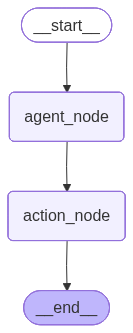

In [ ]:
graph=builder.compile() # 编译状态图，生成一个可执行的状态图对象

# 可视化状态图，展示节点和边的结构
from IPython.display import Image, display 
display(Image(graph.get_graph().draw_mermaid_png()))
# 将状态图转换为Mermaid格式的PNG图片，并在Jupyter Notebook中显示  

# 至此，成功构建了一个完整的图结构graph，并准备好接收用户的请求；

6.调用graph
通过invoke方法调用graph，传入用户请求question，获取Agent的响应。

In [51]:
graph.invoke({"question":"今天的天气怎么样？"}) 
# 调用graph，传入用户请求"今天的天气怎么样？"，获取Agent的响应。


我是一个AI Agent
我正在执行一个动作


{'answer': '执行动作，用户问题：今天的天气怎么样？'}

上面graph.invoke里用户问了一个问题，图中节点的执行流程如下：
1. 用户输入问题"今天的天气怎么样？"，从START节点开始传递给agent_node节点
2. agent_node节点执行，获取用户的问题"今天的天气怎么样？",并输出"我是一个AI Agent"，return一个新的state，包含这个问题
3. action_node节点执行，获取agent_node节点返回的问题，即"今天的天气怎么样？"，输出"我正在执行一个动作"，return 一个新的state，包含这个问题
4. END节点执行，返回用户的问题"今天的天气怎么样？"，并结束图的执行;

不同节点间能够传递信息的原因是节点可以写入图状态中的任何状态通道，其他节点可以读取这个通道中的信息。（这属于Langgraph的默认机制，LangGraph 强制所有节点共享一个状态字典。）

# 使用LangGraph构建大模型的问答流程

0.定义图模式

In [1]:
from langgraph.graph import StateGraph
from typing_extensions import TypedDict
from langgraph.graph import START, END

# 定义输入的模式
class InputState(TypedDict):
    question: str

# 定义输出的模式
class OutputState(TypedDict):
    answer: str

# 将 InputState 和 OutputState 这两个 TypedDict 类型合并成一个更全面的字典类型。
class OverallState(InputState, OutputState):
    pass

1.使用OPenAI 的GPT模型需要使用ChatOpenAI方法，需要将其定义到Agent节点中，用来接收用户输入的问题，调用GPT模型来根据用户的问题生成自然语言的回复相应。

message就是传给大模型的对话历史/提示词（prompt），遵循ChatML格式，包含系统消息、用户消息和模型消息。
SystemMessage是给大模型的系统指令，用于设置模型的行为和规则。
HumanMessage是用户输入的问题，是模型的输入。直接从状态state中提取用户的question字段。


In [2]:
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage

key = "sk-edoptvsonubjhdxwfdklbvhwscmnkmycthcvlomfvpmdevqr"
url = "https://api.siliconflow.cn/v1"

def llm_node(state: InputState) -> OutputState:
    message = [
        SystemMessage(content="你是一个有用的助手。"),
        HumanMessage(content=state["question"])
    ]

    llm = ChatOpenAI(model="Qwen/Qwen2.5-7B-Instruct", # 免费模型
                 api_key=key,base_url=url,
                 temperature=0)
    response = llm.invoke(message)
    return {"answer": response.content}


2.构建图，添加节点，并进行图结构的编译

In [5]:
# 明确指定它的输入和输出数据的结构或模式
builder = StateGraph(OverallState, input=InputState, output=OutputState)

# 添加节点
builder.add_node("llm_node", llm_node)

# 添加边
builder.add_edge(START, "llm_node")
builder.add_edge("llm_node", END)

# 编译图
graph = builder.compile()

C:\Users\30732\AppData\Local\Temp\ipykernel_17432\3489421291.py:2: LangGraphDeprecatedSinceV05: `input` is deprecated and will be removed. Please use `input_schema` instead. Deprecated in LangGraph V0.5 to be removed in V2.0.
  builder = StateGraph(OverallState, input=InputState, output=OutputState)
C:\Users\30732\AppData\Local\Temp\ipykernel_17432\3489421291.py:2: LangGraphDeprecatedSinceV05: `output` is deprecated and will be removed. Please use `output_schema` instead. Deprecated in LangGraph V0.5 to be removed in V2.0.
  builder = StateGraph(OverallState, input=InputState, output=OutputState)


3.测试

In [6]:
final_answer = graph.invoke({"question":"你好，我用来测试"})
print(final_answer)
print(final_answer["answer"])


{'answer': '你好！很高兴见到你。你可以详细说明一下你是如何使用我的，或者你有什么具体的问题需要帮助吗？我会尽力提供帮助。'}
你好！很高兴见到你。你可以详细说明一下你是如何使用我的，或者你有什么具体的问题需要帮助吗？我会尽力提供帮助。


# 使用LangGraph构建大模型的问答流程-进阶

In [1]:
from langgraph.graph import StateGraph
from typing_extensions import TypedDict
from langgraph.graph import START, END
from typing import Optional

# 定义输入的模式
class InputState(TypedDict):
    question: str
    llm_answer: Optional[str] # 添加一个可选字段 llm_answer，用于存储模型的回复

# 定义输出的模式
class OutputState(TypedDict):
    answer: str

# 将 InputState 和 OutputState 这两个 TypedDict 类型合并成一个更全面的字典类型。
class OverallState(InputState, OutputState):
    pass

如果想在原有的图结构中构建更复杂的功能，则只需要新定义一个Python函数即可，正如下边的action_node所示；
其他的流程和上一版保持不变。

In [2]:
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage

key = "sk-edoptvsonubjhdxwfdklbvhwscmnkmycthcvlomfvpmdevqr"
url = "https://api.siliconflow.cn/v1"

def llm_node(state: InputState):
    message = [
        SystemMessage(content="你是一个有用的助手。"),
        HumanMessage(content=state["question"])
    ]

    llm = ChatOpenAI(model="Qwen/Qwen2.5-7B-Instruct", # 免费模型
                 api_key=key,base_url=url,
                 temperature=0)
    response = llm.invoke(message)
    return {"llm_answer": response.content}

# 定义一个节点，用于将模型的回复翻译成英文
def action_node(state: InputState):
    message =[
        SystemMessage(content="无论接收到什么语言的文本，请翻译成英文"),
        HumanMessage(content=state["llm_answer"])
    ]
    llm = ChatOpenAI(model="Qwen/Qwen2.5-7B-Instruct", # 免费模型
                 api_key=key,base_url=url,
                 temperature=0)
    response = llm.invoke(message)
    return {"answer": response.content}

构件图，添加节点和边，并进行图的编译

In [3]:
# 明确指定它的输入和输出数据的结构或模式
builder = StateGraph(OverallState, input=InputState, output=OutputState)

# 添加节点
builder.add_node("llm_node", llm_node)
builder.add_node("action_node", action_node)


# 添加便
builder.add_edge(START, "llm_node")
builder.add_edge("llm_node", "action_node")
builder.add_edge("action_node", END)

# 编译图
graph = builder.compile()

C:\Users\30732\AppData\Local\Temp\ipykernel_2548\1454406898.py:2: LangGraphDeprecatedSinceV05: `input` is deprecated and will be removed. Please use `input_schema` instead. Deprecated in LangGraph V0.5 to be removed in V2.0.
  builder = StateGraph(OverallState, input=InputState, output=OutputState)
C:\Users\30732\AppData\Local\Temp\ipykernel_2548\1454406898.py:2: LangGraphDeprecatedSinceV05: `output` is deprecated and will be removed. Please use `output_schema` instead. Deprecated in LangGraph V0.5 to be removed in V2.0.
  builder = StateGraph(OverallState, input=InputState, output=OutputState)


测试

In [4]:
final_answer = graph.invoke({"question":"你好，我用来测试"})

print(final_answer["answer"])

Hello! Nice to meet you. Could you tell me what exactly you need to be tested? I will do my best to assist you. Is it software testing, network testing, or something else?


相较于LangChain,LangGraph展现出更高的灵活性和可扩展性。在LangGraph中，可以通过各个函数定义节点的核心逻辑，并通过边来确定输入和输出的关系。此外，节点函数在定义时也能自主生成和管理中间状态的信息；

虽然在本实例中，我们只需要一个节点来处理用户的问题，但是LangGraph的灵活性使得我们可以根据需要添加更多的节点，来处理更复杂的任务。

另外本实例是通过LangChain实现大模型的接入，但从节点函数的定义逻辑来看，完全可以不依赖LangChain，直接在节点函数中实现大模型的调用。，而采用原生方法接入。
尽管LangGraph基于LangChain表达式语言构建，但它完全具备独立运行的能力。